# Life Expectancy Prediction — EDA & Regression Modeling (Beginner Version)

This notebook walks through:
1. Loading and exploring the data (EDA)
2. Cleaning missing values
3. Encoding categorical variables
4. Training Linear, Lasso, and Ridge regression models
5. Comparing model performance

This is a simplified, entry-level workflow — no `Pipeline` objects and no hyperparameter
tuning (`GridSearchCV`). Every step is done manually and explicitly so it's easy to follow.

**Dataset:** WHO Life Expectancy dataset (2000–2015, 193 countries)

## 1. Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

## 2. Load the Data

In [5]:
df = pd.read_csv("/Users/luxdevhq/Desktop/Data Science CH07/Machine Learning/Life Expectancy/Life Expectancy Data.csv")

# Clean up column names (dataset has trailing/leading whitespace in headers)
df.columns = [c.strip() for c in df.columns]

print(f"Shape: {df.shape}")
df.head()

Shape: (2938, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


## 3. Exploratory Data Analysis (EDA)

### 3.1 Structure & data types

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

### 3.2 Summary statistics

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2938.0,2.007519e+03,4.613841e+00,2000.00000,2004.000000,2.008000e+03,2.012000e+03,2.015000e+03
Life expectancy,2928.0,6.922493e+01,9.523867e+00,36.30000,63.100000,7.210000e+01,7.570000e+01,8.900000e+01
Adult Mortality,2928.0,1.647964e+02,1.242921e+02,1.00000,74.000000,1.440000e+02,2.280000e+02,7.230000e+02
infant deaths,2938.0,3.030395e+01,1.179265e+02,0.00000,0.000000,3.000000e+00,2.200000e+01,1.800000e+03
Alcohol,2744.0,4.602861e+00,4.052413e+00,0.01000,0.877500,3.755000e+00,7.702500e+00,1.787000e+01
percentage expenditure,2938.0,7.382513e+02,1.987915e+03,0.00000,4.685343,6.491291e+01,4.415341e+02,1.947991e+04
Hepatitis B,2385.0,8.094046e+01,2.507002e+01,1.00000,77.000000,9.200000e+01,9.700000e+01,9.900000e+01
Measles,2938.0,2.419592e+03,1.146727e+04,0.00000,0.000000,1.700000e+01,3.602500e+02,2.121830e+05
BMI,2904.0,3.832125e+01,2.004403e+01,1.00000,19.300000,4.350000e+01,5.620000e+01,8.730000e+01
under-five deaths,2938.0,4.203574e+01,1.604455e+02,0.00000,0.000000,4.000000e+00,2.800000e+01,2.500000e+03


### 3.3 Missing values

In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})

,missing_count,missing_pct
Population,652,22.19
Hepatitis B,553,18.82
GDP,448,15.25
Total expenditure,226,7.69
Alcohol,194,6.60
Income composition of resources,167,5.68
Schooling,163,5.55
BMI,34,1.16
thinness 1-19 years,34,1.16
thinness 5-9 years,34,1.16


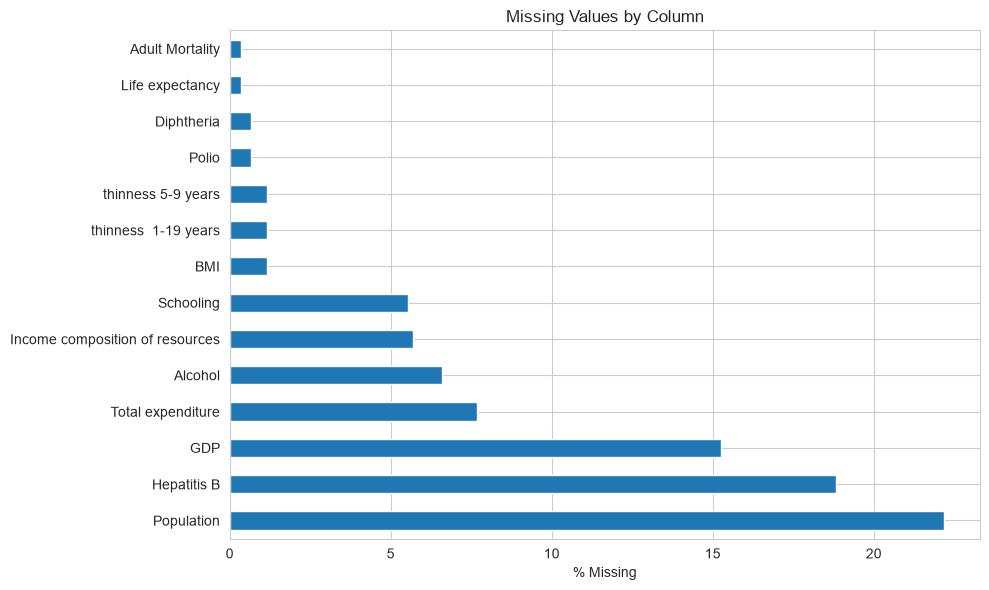

In [9]:
plt.figure(figsize=(10, 6))
missing_pct.plot(kind='barh')
plt.xlabel('% Missing')
plt.title('Missing Values by Column')
plt.tight_layout()
plt.show()

### 3.4 Target variable distribution — Life Expectancy

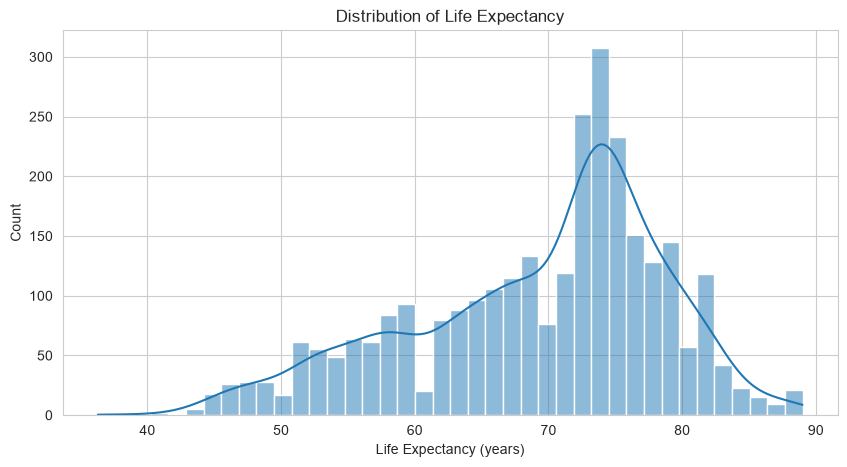

count    2928.000000
mean       69.224932
std         9.523867
min        36.300000
25%        63.100000
50%        72.100000
75%        75.700000
max        89.000000
Name: Life expectancy, dtype: float64


In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Life expectancy'].dropna(), kde=True, bins=40)
plt.title('Distribution of Life Expectancy')
plt.xlabel('Life Expectancy (years)')
plt.show()

print(df['Life expectancy'].describe())

### 3.5 Life expectancy by Status (Developed vs Developing)

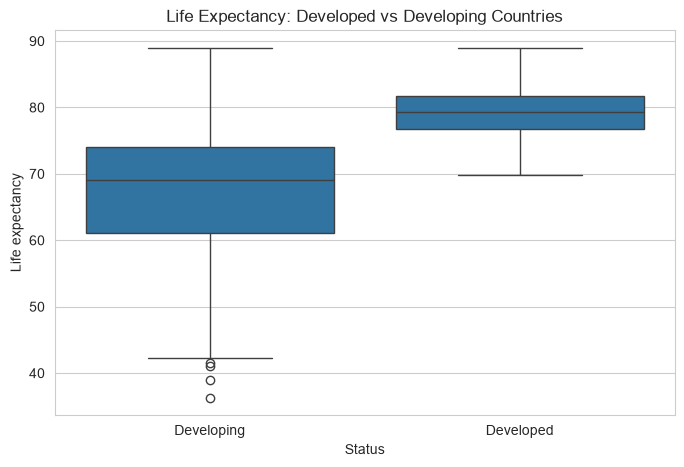

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Status', y='Life expectancy')
plt.title('Life Expectancy: Developed vs Developing Countries')
plt.show()

### 3.6 Life expectancy trend over years

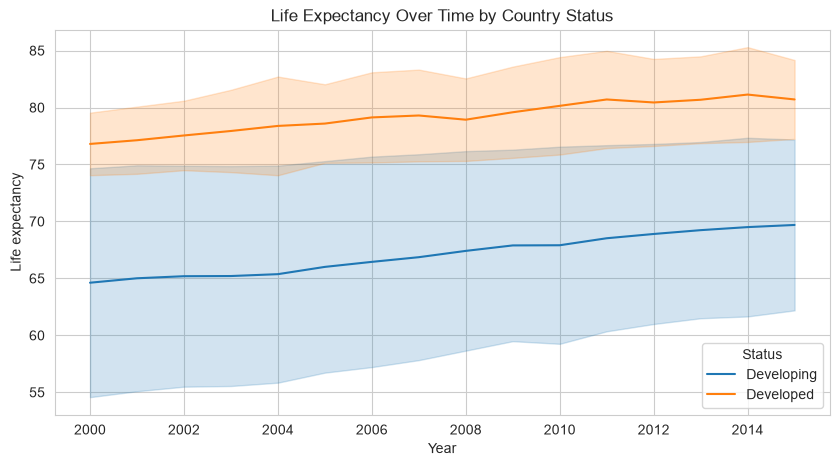

In [12]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Year', y='Life expectancy', hue='Status', errorbar='sd')
plt.title('Life Expectancy Over Time by Country Status')
plt.show()

### 3.7 Correlation heatmap (numeric features)

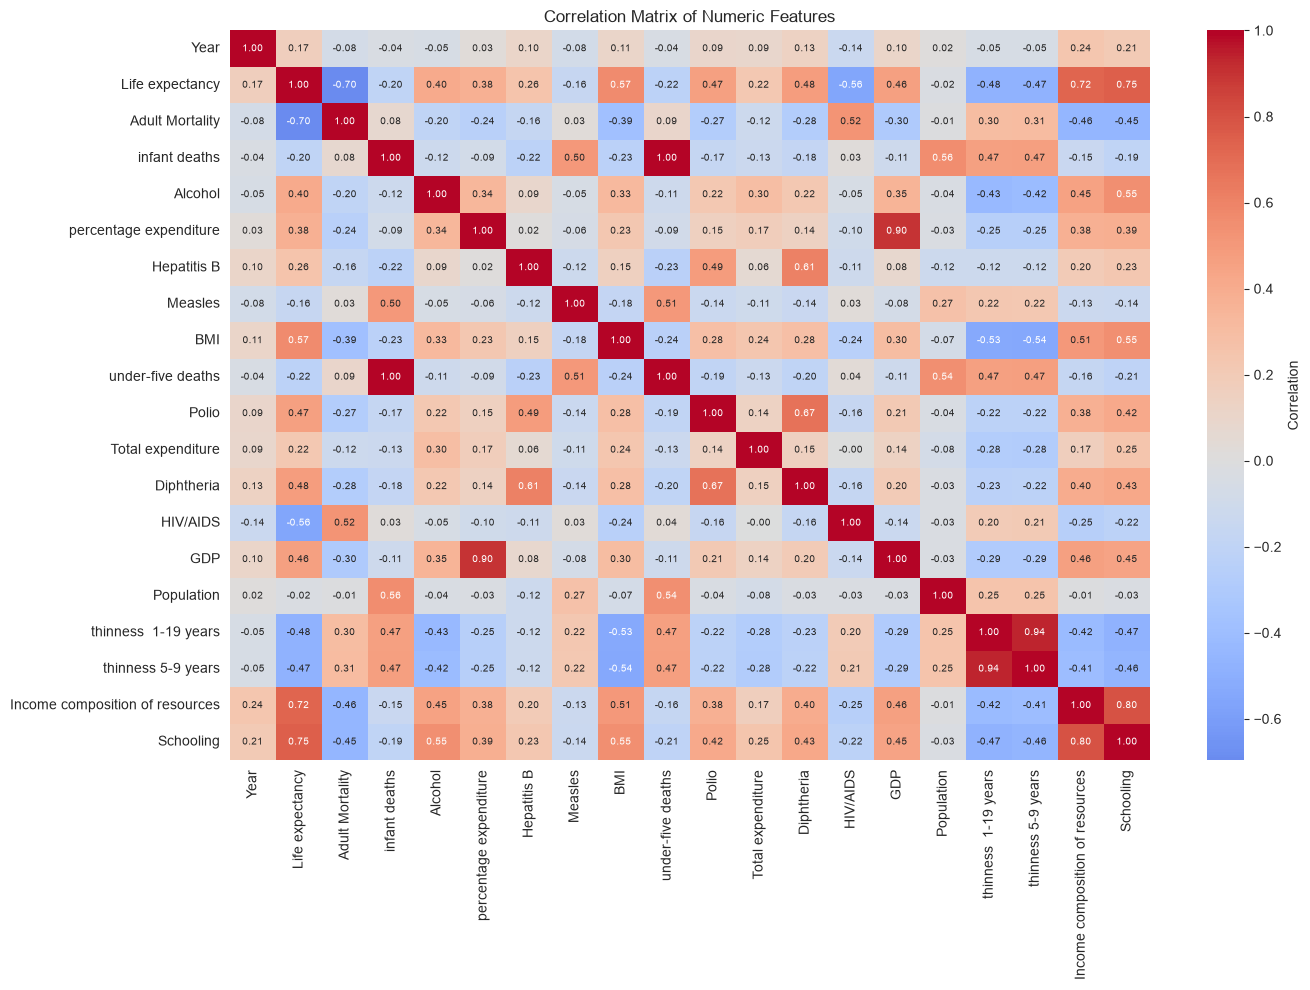

In [13]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            annot_kws={'size': 7}, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

### 3.8 Top correlated features with Life Expectancy

Schooling                          0.751975
Income composition of resources    0.724776
Adult Mortality                   -0.696359
BMI                                0.567694
HIV/AIDS                          -0.556556
Diphtheria                         0.479495
thinness  1-19 years              -0.477183
thinness 5-9 years                -0.471584
Polio                              0.465556
GDP                                0.461455
Alcohol                            0.404877
percentage expenditure             0.381864
Hepatitis B                        0.256762
under-five deaths                 -0.222529
Total expenditure                  0.218086
infant deaths                     -0.196557
Year                               0.170033
Measles                           -0.157586
Population                        -0.021538
Name: Life expectancy, dtype: float64


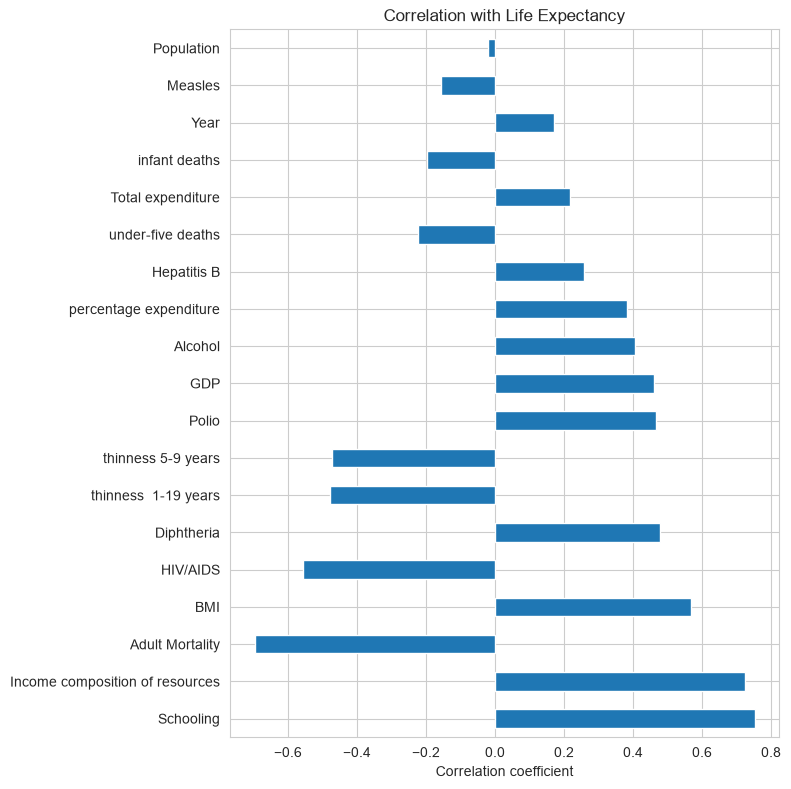

In [14]:
target_corr = corr['Life expectancy'].drop('Life expectancy').sort_values(key=abs, ascending=False)
print(target_corr)

plt.figure(figsize=(8, 8))
target_corr.plot(kind='barh')
plt.title('Correlation with Life Expectancy')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

### 3.9 Relationship between key predictors and Life Expectancy

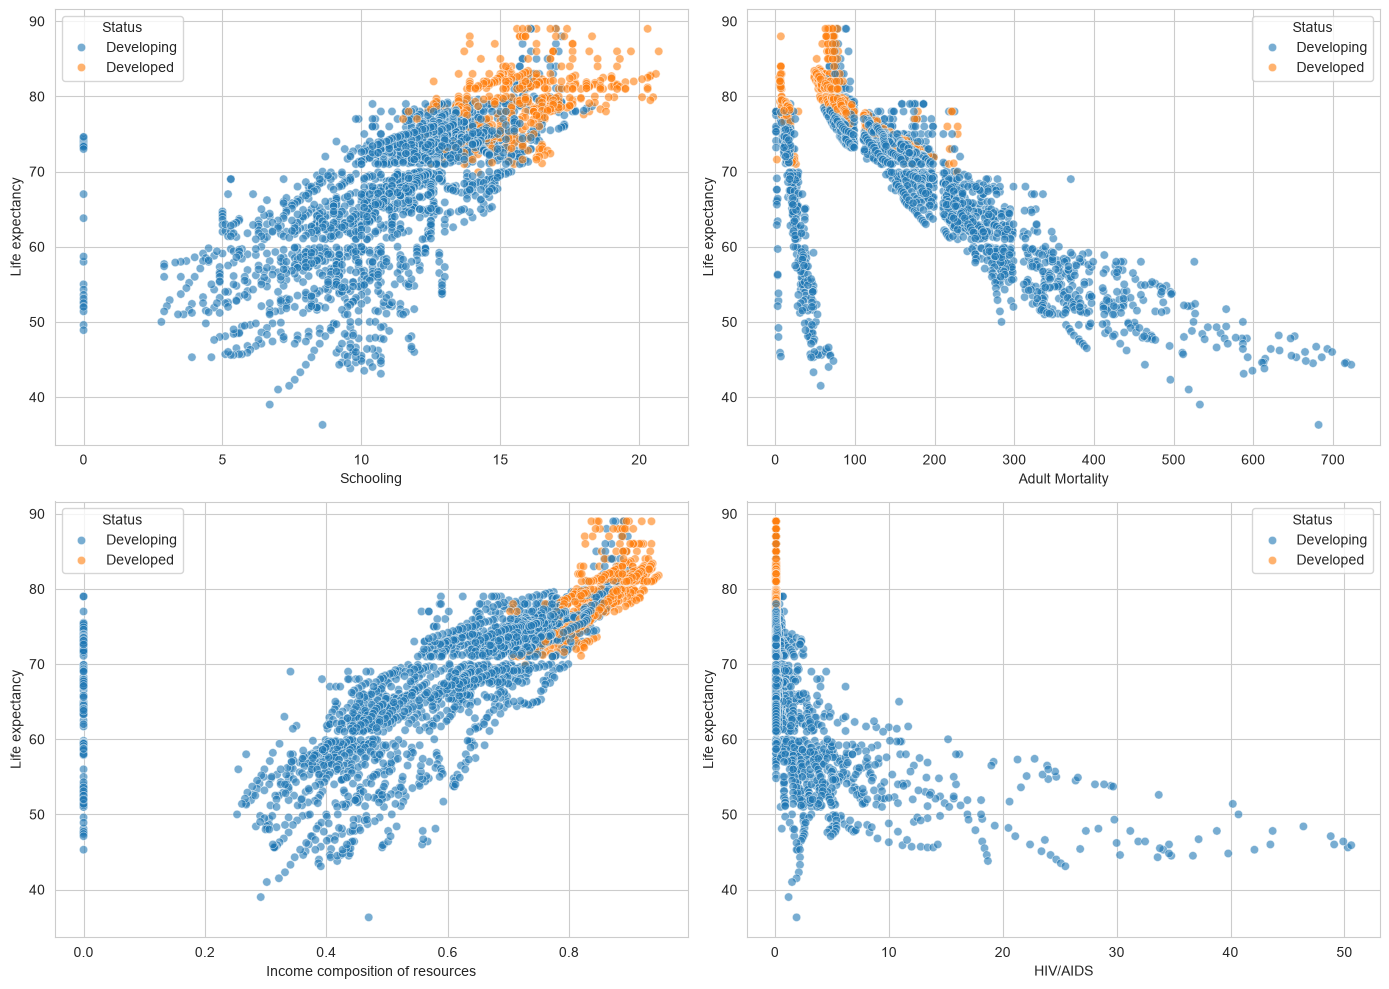

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.scatterplot(data=df, x='Schooling', y='Life expectancy', hue='Status', ax=axes[0,0], alpha=0.6)
sns.scatterplot(data=df, x='Adult Mortality', y='Life expectancy', hue='Status', ax=axes[0,1], alpha=0.6)
sns.scatterplot(data=df, x='Income composition of resources', y='Life expectancy', hue='Status', ax=axes[1,0], alpha=0.6)
sns.scatterplot(data=df, x='HIV/AIDS', y='Life expectancy', hue='Status', ax=axes[1,1], alpha=0.6)
plt.tight_layout()
plt.show()

## 4. Data Cleaning

Steps (done manually, step by step):
- Drop rows where the target (`Life expectancy`) is missing — we can't train or evaluate on those
- Drop the `Country` column — it has ~190 unique values, which would create too many columns
  for a simple model and adds little generalizable signal (a country name itself doesn't
  cause a life expectancy value)
- Fill missing numeric values with the **median** of each column
- Fill missing `Status` values (if any) with the most frequent value

In [16]:
# Drop rows with missing target
df_clean = df.dropna(subset=['Life expectancy']).copy()

# Drop Country (too many unique categories for a simple model)
df_clean = df_clean.drop(columns=['Country'])

print(f"Shape after cleaning: {df_clean.shape}")
df_clean.isnull().sum()[df_clean.isnull().sum() > 0]

Shape after cleaning: (2928, 21)


Alcohol                            193
Hepatitis B                        553
BMI                                 32
Polio                               19
Total expenditure                  226
Diphtheria                          19
GDP                                443
Population                         644
thinness  1-19 years                32
thinness 5-9 years                  32
Income composition of resources    160
Schooling                          160
dtype: int64

In [17]:
# Fill missing numeric columns with the median
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill missing Status with the mode (most frequent value), just in case
df_clean['Status'] = df_clean['Status'].fillna(df_clean['Status'].mode()[0])

print("Missing values remaining:", df_clean.isnull().sum().sum())

Missing values remaining: 0


## 5. Encoding the Categorical Variable

`Status` only has two values: `Developing` and `Developed`. We'll use `pd.get_dummies()`
to convert it into a single 0/1 column (this is effectively one-hot encoding, done manually
with pandas instead of a scikit-learn transformer).

In [18]:
df_clean['Status'].value_counts()

Status
Developing    2416
Developed      512
Name: count, dtype: int64

In [19]:
df_encoded = pd.get_dummies(df_clean, columns=['Status'], drop_first=True)

# drop_first=True turns Status into one column: Status_Developing (1 = Developing, 0 = Developed)
df_encoded.head()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Status_Developing
0,2015,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1,True
1,2014,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0,True
2,2013,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9,True
3,2012,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8,True
4,2011,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5,True


## 6. Train/Test Split

We separate the target (`Life expectancy`) from the features, then split into training
(80%) and testing (20%) sets.

In [20]:
X = df_encoded.drop(columns=['Life expectancy'])
y = df_encoded['Life expectancy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")

Training set: (2342, 20)
Testing set:  (586, 20)


### 6.1 Feature scaling

Lasso and Ridge regression are sensitive to the scale of features (their penalty term adds
up the size of coefficients, so features on bigger numeric scales would be unfairly penalized
more). We scale all features to have mean 0 and standard deviation 1 using `StandardScaler`.

Note: we `fit` the scaler only on the training data, then use it to `transform` both
train and test — this avoids leaking information from the test set.

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.head()

,Year,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Status_Developing
2268,0.966331,-0.322817,-0.256632,1.238372,0.009541,0.612859,-0.212647,1.011843,-0.263476,0.452644,1.656679,0.374228,-0.326377,-0.068959,-0.183314,-0.623696,-0.619571,0.676827,0.609119,0.457259
1680,-1.205595,0.103723,-0.265419,-0.105060,-0.183638,0.222202,-0.212647,-0.587068,-0.269883,0.238553,-0.685035,0.249314,-0.326377,-0.197190,-0.195603,0.688496,0.664257,0.262627,0.148097,0.457259
2785,0.097560,1.689162,0.543056,-0.284526,-0.375135,0.135390,0.085843,-0.927902,0.614251,0.281371,-0.697469,0.166037,1.082164,-0.362391,-0.169449,0.552752,0.531447,0.233041,0.086627,0.457259
2512,0.097560,-0.837884,-0.265419,0.602549,3.824156,0.395827,-0.210460,0.921622,-0.269883,0.666734,1.383133,0.665696,-0.326377,3.704993,-0.007881,-0.804688,-0.796651,1.317852,1.131611,-2.186942
1090,1.617908,0.876322,-0.230268,-0.199921,-0.375135,0.178796,-0.199266,-0.592080,-0.231442,0.195735,-0.059196,0.207675,0.271771,-0.450405,-0.194511,0.507504,0.465042,-1.029283,-0.866153,0.457259


## 7. Model Training & Evaluation

We train three models directly (no pipelines, no tuning — just default / simple fixed settings):

- **Linear Regression** — no regularization
- **Lasso Regression** — L1 regularization, using scikit-learn's default `alpha=1.0`
- **Ridge Regression** — L2 regularization, using scikit-learn's default `alpha=1.0`

For each model we compute:
- **R²** (how much variance in life expectancy the model explains — closer to 1 is better)
- **RMSE** (Root Mean Squared Error — average prediction error, in years, penalizing big misses more)
- **MAE** (Mean Absolute Error — average prediction error, in years)

### 7.1 Linear Regression

In [22]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)

linear_r2 = r2_score(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_mae = mean_absolute_error(y_test, y_pred_linear)

print(f"Linear Regression Results:")
print(f"  R2:   {linear_r2:.4f}")
print(f"  RMSE: {linear_rmse:.4f}")
print(f"  MAE:  {linear_mae:.4f}")

Linear Regression Results:
  R2:   0.8195
  RMSE: 3.9517
  MAE:  2.9273


### 7.2 Lasso Regression

In [23]:
lasso_model = Lasso(alpha=1.0)   # default alpha, no tuning
lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_test_scaled)

lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)

print(f"Lasso Regression Results (alpha=1.0):")
print(f"  R2:   {lasso_r2:.4f}")
print(f"  RMSE: {lasso_rmse:.4f}")
print(f"  MAE:  {lasso_mae:.4f}")

Lasso Regression Results (alpha=1.0):
  R2:   0.7880
  RMSE: 4.2821
  MAE:  3.1384


### 7.3 Ridge Regression

In [24]:
ridge_model = Ridge(alpha=1.0)   # default alpha, no tuning
ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

print(f"Ridge Regression Results (alpha=1.0):")
print(f"  R2:   {ridge_r2:.4f}")
print(f"  RMSE: {ridge_rmse:.4f}")
print(f"  MAE:  {ridge_mae:.4f}")

Ridge Regression Results (alpha=1.0):
  R2:   0.8192
  RMSE: 3.9542
  MAE:  2.9268


## 8. Model Comparison

In [25]:
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Lasso Regression', 'Ridge Regression'],
    'R2': [linear_r2, lasso_r2, ridge_r2],
    'RMSE': [linear_rmse, lasso_rmse, ridge_rmse],
    'MAE': [linear_mae, lasso_mae, ridge_mae]
}).set_index('Model').round(4)

results_df

,R2,RMSE,MAE
Model,,,
Linear Regression,0.8195,3.9517,2.9273
Lasso Regression,0.7880,4.2821,3.1384
Ridge Regression,0.8192,3.9542,2.9268


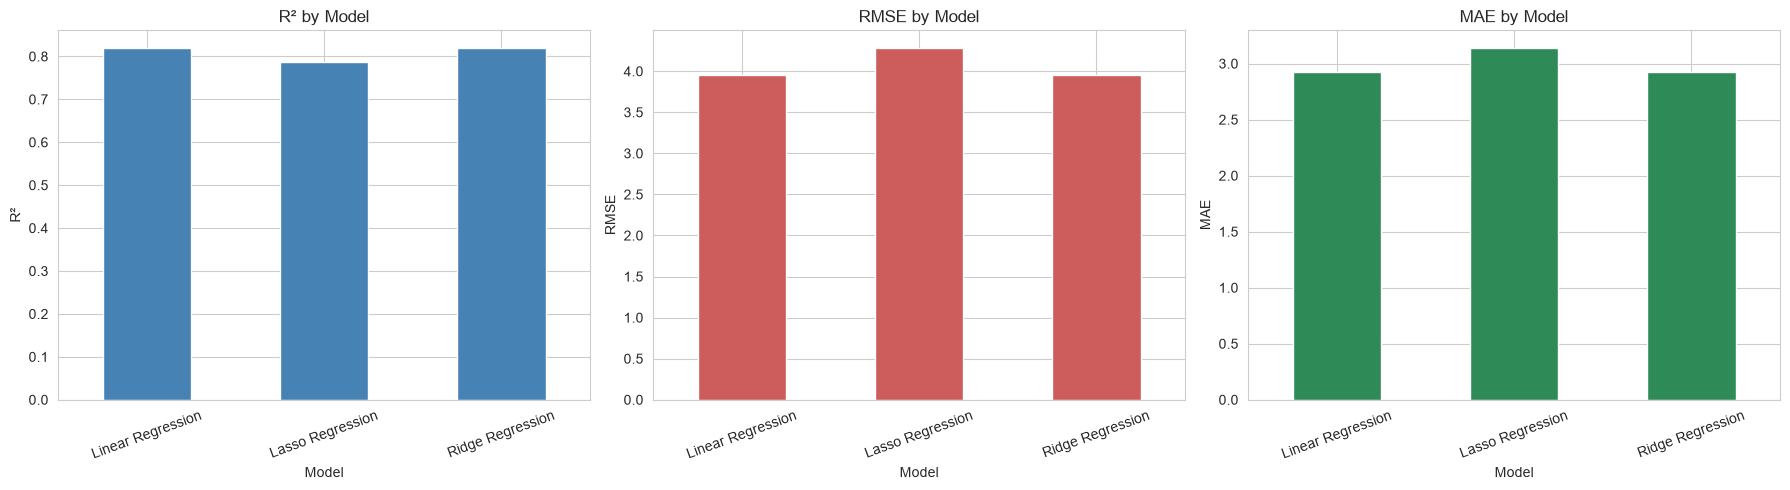

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

results_df['R2'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('R² by Model')
axes[0].set_ylabel('R²')
axes[0].tick_params(axis='x', rotation=20)

results_df['RMSE'].plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('RMSE by Model')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=20)

results_df['MAE'].plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('MAE by Model')
axes[2].set_ylabel('MAE')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### 8.1 Feature coefficients — Linear Regression

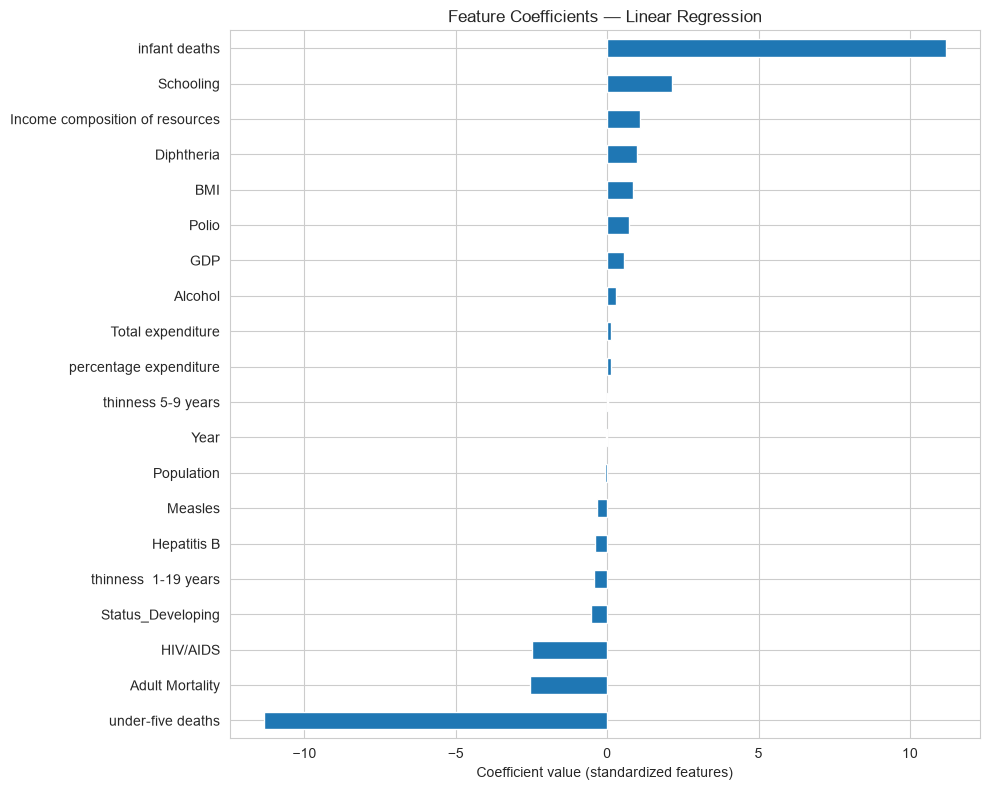

In [27]:
coefs = pd.Series(linear_model.coef_, index=X_train.columns)
coefs_sorted = coefs.reindex(coefs.abs().sort_values(ascending=False).index)

plt.figure(figsize=(10, 8))
coefs_sorted.sort_values().plot(kind='barh')
plt.title('Feature Coefficients — Linear Regression')
plt.xlabel('Coefficient value (standardized features)')
plt.tight_layout()
plt.show()

## 9. Conclusions

- All three models were trained with simple, default settings (no tuning), which is a good
  starting baseline before optimizing further.
- Compare the R², RMSE, and MAE values above to see which model fit best on this run.
- Lasso can shrink some feature coefficients all the way to 0, effectively performing feature
  selection — check the printed coefficients above to see which features it dropped.
- Ridge shrinks coefficients but rarely to exactly 0.

### Suggested next steps (once you're ready to go beyond entry-level)
- Try different `alpha` values manually (e.g., 0.1, 1, 10) for Lasso/Ridge and see how the
  metrics change
- Once comfortable, explore `GridSearchCV` to automate finding the best `alpha`
- Explore encoding `Country` instead of dropping it, and compare results
- Try tree-based models (Random Forest, Decision Tree) for comparison